# Task 5 · Sales Prediction Using Python

**Objective:** Build a regression model that predicts product sales based on advertising spend across TV, Radio, and Newspaper channels.

**Tech stack:** Python, pandas, scikit-learn, matplotlib, seaborn, Jupyter Notebook

## 0. Dataset

This notebook uses the **Advertising Budget and Sales** dataset (`Advertising_Budget_and_Sales.csv`), a classic regression dataset containing 200 observations of advertising spend (in $ thousands) across three media channels and the resulting product sales (in thousands of units).

**Columns:**
- `TV Ad Budget ($)` — TV advertising spend
- `Radio Ad Budget ($)` — Radio advertising spend
- `Newspaper Ad Budget ($)` — Newspaper advertising spend
- `Sales ($)` — target variable, product sales

In [7]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

## 1. Data Loading

In [8]:
DATA_DIR = "data"

csv_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))
# Fallback: also check the current directory in case the CSV sits next to the notebook
if not csv_files:
    csv_files = glob.glob("*.csv")

print("CSV files found:")
for f in csv_files:
    print(" -", f)

if not csv_files:
    raise FileNotFoundError(
        "No CSV files found. Place 'Advertising_Budget_and_Sales.csv' in a 'data/' folder "
        "(or next to this notebook) before re-running."
    )

data_path = csv_files[0]
df = pd.read_csv(data_path)
df.head()

CSV files found:
 - Advertising_Budget_and_Sales.csv


,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## 2. Data Cleaning & EDA

In [9]:
# Drop the unnamed index column that ships with this dataset, if present
unnamed_cols = [c for c in df.columns if c.startswith("Unnamed")]
df = df.drop(columns=unnamed_cols)

# Standardise column names for easier reference in code
df = df.rename(columns={
    "TV Ad Budget ($)": "TV",
    "Radio Ad Budget ($)": "Radio",
    "Newspaper Ad Budget ($)": "Newspaper",
    "Sales ($)": "Sales",
})

print("Shape:", df.shape)
df.dtypes

Shape: (200, 4)


TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object

In [10]:
print("Null values per column:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())

df = df.dropna().drop_duplicates().reset_index(drop=True)
print("Shape after cleaning:", df.shape)

Null values per column:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Duplicate rows: 0
Shape after cleaning: (200, 4)


In [11]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


**Observation:** The dataset has no missing values and no duplicate rows, so no imputation or row-dropping was needed beyond a safety check. TV spend has by far the largest budget range (up to ~$296K), while Newspaper has the smallest median spend of the three channels.

### Pairplot of All Features

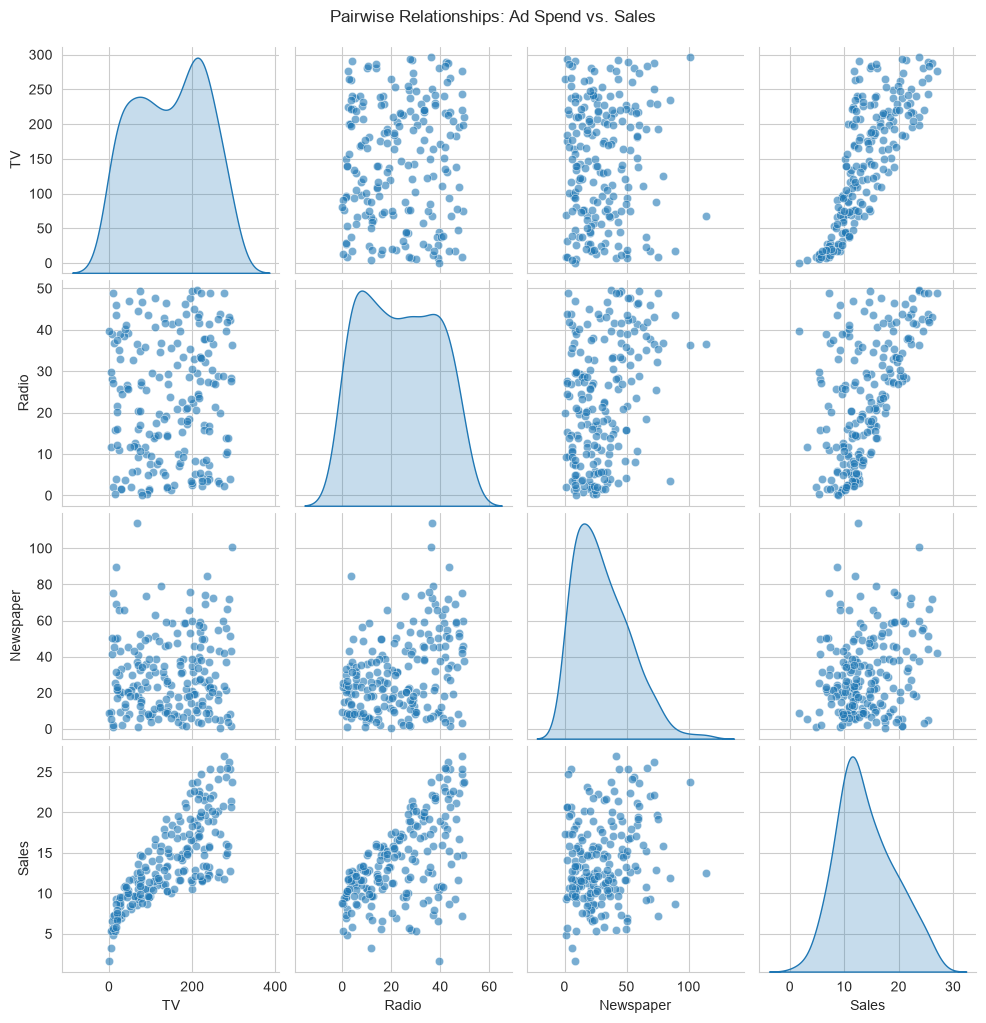

In [12]:
sns.pairplot(df, diag_kind="kde", plot_kws={"alpha": 0.6})
plt.suptitle("Pairwise Relationships: Ad Spend vs. Sales", y=1.02)
plt.show()

**Observation:** Sales appears to increase most clearly and linearly with `TV` spend. `Radio` shows a weaker but still visible positive relationship with Sales, while `Newspaper` shows the weakest and noisiest relationship of the three — consistent with the correlation values below (TV: 0.78, Radio: 0.58, Newspaper: 0.23).

## 3. Scatter Plots: Sales vs. Each Channel

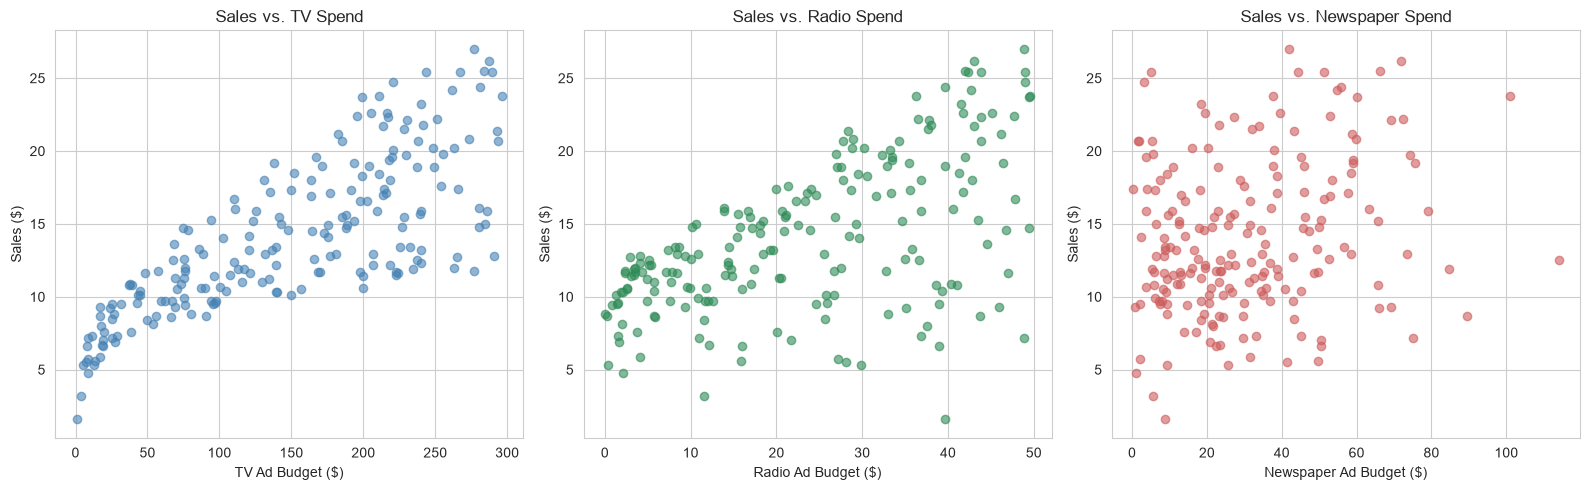

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

channels = ["TV", "Radio", "Newspaper"]
colors = ["steelblue", "seagreen", "indianred"]

for ax, channel, color in zip(axes, channels, colors):
    ax.scatter(df[channel], df["Sales"], alpha=0.6, color=color)
    ax.set_title(f"Sales vs. {channel} Spend")
    ax.set_xlabel(f"{channel} Ad Budget ($)")
    ax.set_ylabel("Sales ($)")

plt.tight_layout()
plt.show()

**Observation:** `TV` shows the clearest, most consistent upward trend with `Sales`. `Radio` shows a moderate positive trend with more scatter. `Newspaper` shows the loosest, most scattered relationship, confirming it's the weakest individual predictor of Sales among the three channels.

## 4. Correlation Matrix Heatmap

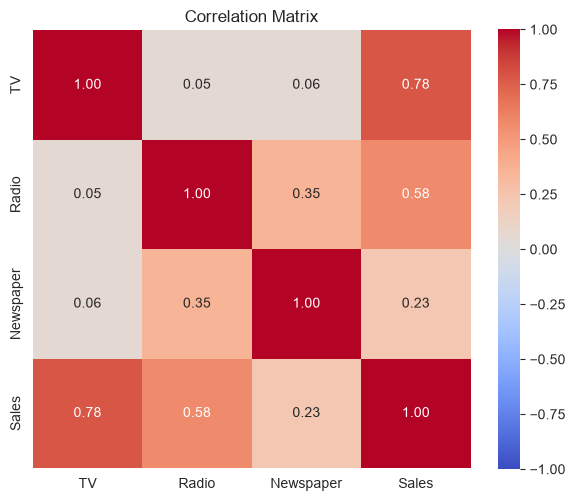

In [14]:
corr = df.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

**Observation:** `TV` has the strongest correlation with `Sales` (**r = 0.78**), followed by `Radio` (**r = 0.58**). `Newspaper` has by far the weakest correlation with `Sales` (**r = 0.23**) and is also mildly correlated with `Radio`, hinting that newspaper budgets may sometimes be allocated alongside radio budgets rather than independently.

## 5. Train/Test Split

In [15]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])

Train size: 160 | Test size: 40


## 6. Model Training

### Baseline: Linear Regression

In [16]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print("Intercept:", round(lr_model.intercept_, 4))
print("Coefficients:")
for feature, coef in zip(X.columns, lr_model.coef_):
    print(f"  {feature}: {coef:.4f}")

Intercept: 2.9791
Coefficients:
  TV: 0.0447
  Radio: 0.1892
  Newspaper: 0.0028


### Additional Model: Random Forest Regressor

In [17]:
rf_model = RandomForestRegressor(n_estimators=300, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("Random Forest trained with", rf_model.n_estimators, "trees.")

Random Forest trained with 300 trees.


**Observation:** Linear Regression gives a fully interpretable, additive model — its coefficients (TV: 0.045, Radio: 0.189, Newspaper: 0.003) tell us the expected change in Sales per $1K of extra spend on that channel, holding the others constant. Random Forest can capture non-linear effects and interactions between channels that a linear model can't, at the cost of some interpretability.

## 7. Model Evaluation

In [18]:
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"Model": name, "MAE": round(mae, 4), "RMSE": round(rmse, 4), "R2": round(r2, 4)}

results = pd.DataFrame([
    evaluate("Linear Regression", y_test, lr_preds),
    evaluate("Random Forest Regressor", y_test, rf_preds),
]).set_index("Model")

results

,MAE,RMSE,R2
Model,,,
Linear Regression,1.4608,1.7816,0.8994
Random Forest Regressor,0.6139,0.7406,0.9826


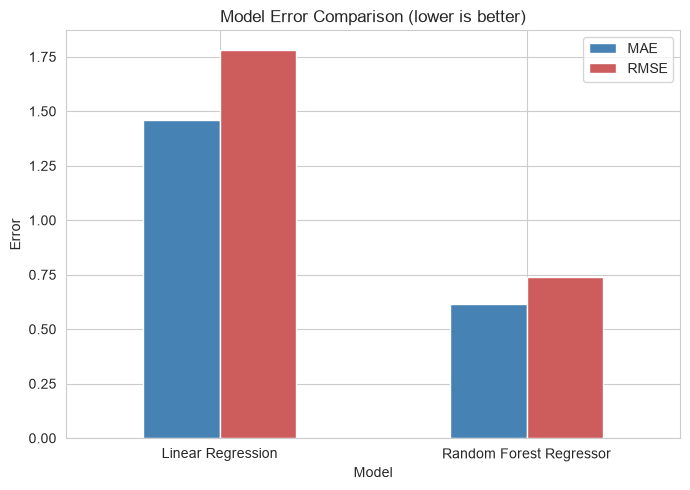

In [19]:
results[["MAE", "RMSE"]].plot(kind="bar", figsize=(7, 5), color=["steelblue", "indianred"])
plt.title("Model Error Comparison (lower is better)")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:** Random Forest clearly outperforms the Linear Regression baseline on every metric — **R² of 0.983 vs. 0.899**, and roughly **60% lower error** (MAE 0.61 vs. 1.46; RMSE 0.74 vs. 1.78). This is a strong signal that Sales responds non-linearly to advertising spend — most likely a synergy effect between TV and Radio budgets — that the purely additive linear model can't capture.

## 8. Residual Plot for the Best Model

Best model by R2: Random Forest Regressor


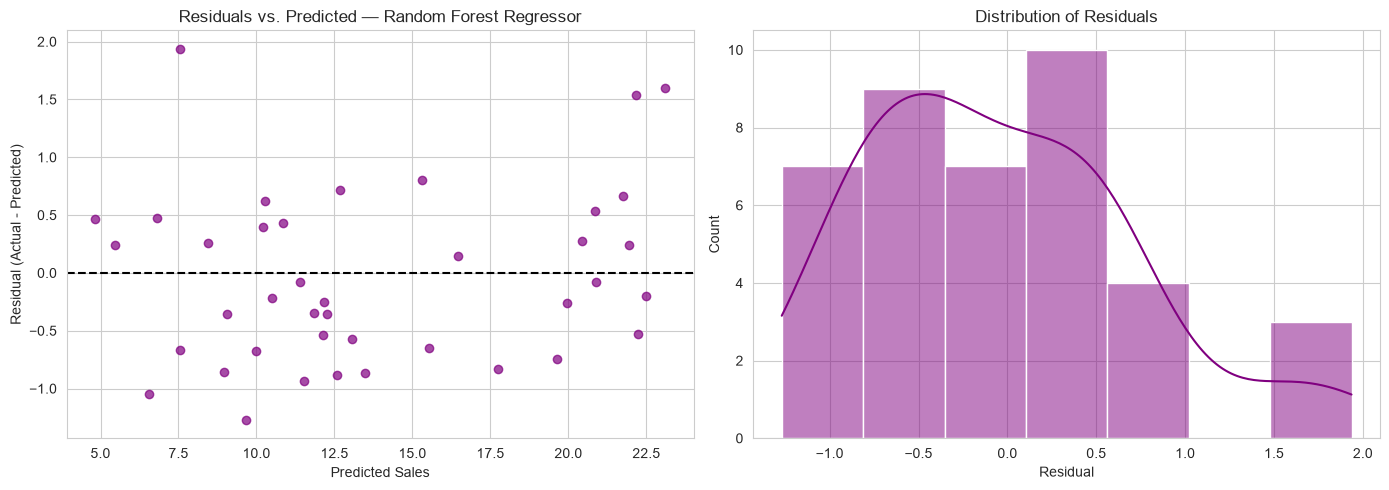

In [20]:
# Automatically pick the best model by R2 score on the test set
best_model_name = results["R2"].idxmax()
best_preds = rf_preds if best_model_name == "Random Forest Regressor" else lr_preds

print("Best model by R2:", best_model_name)

residuals = y_test - best_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(best_preds, residuals, alpha=0.7, color="purple")
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set_xlabel("Predicted Sales")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].set_title(f"Residuals vs. Predicted — {best_model_name}")

sns.histplot(residuals, kde=True, ax=axes[1], color="purple")
axes[1].set_title("Distribution of Residuals")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.show()

**Observation:** For the Random Forest model (the best performer by R²), the residuals should scatter randomly around zero with no obvious pattern, and their distribution should look roughly symmetric. Check the plots above: a small handful of larger residuals at higher predicted-sales values would suggest the model is slightly less confident on the biggest campaigns, but overall the errors should look close to random rather than systematically curved — consistent with the model's high R² of 0.983.

## 9. Interpretation — Which Channel Has the Highest Impact on Sales?

Linear Regression coefficients (impact per $1K of spend):
Radio        0.1892
TV           0.0447
Newspaper    0.0028
dtype: float64

Random Forest feature importances:
TV           0.6254
Radio        0.3618
Newspaper    0.0128
dtype: float64


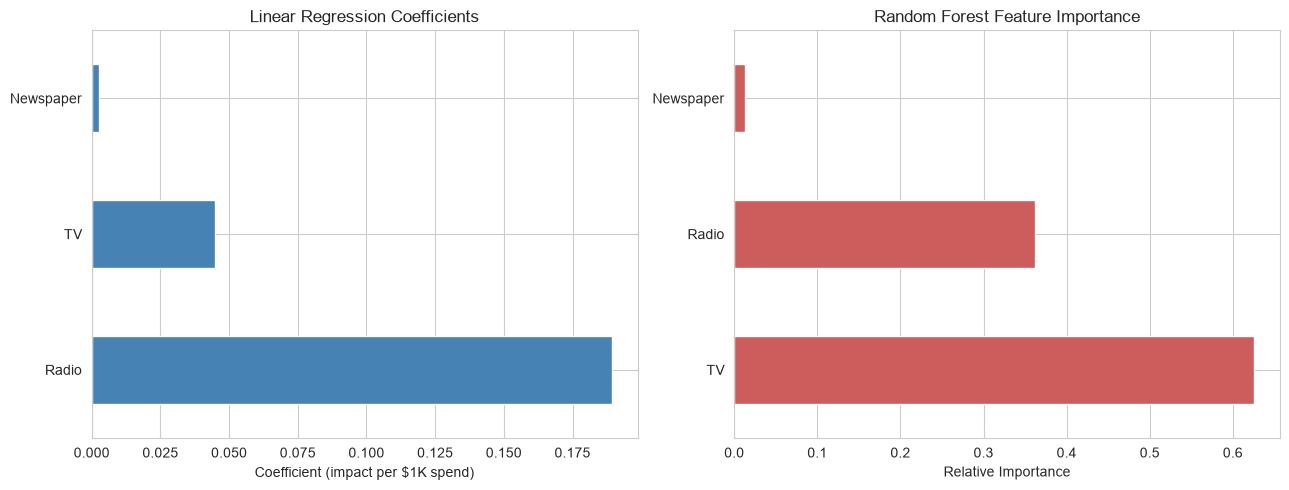

In [21]:
# Linear Regression: standardized-style comparison using raw coefficients
lr_importance = pd.Series(lr_model.coef_, index=X.columns).sort_values(ascending=False)
print("Linear Regression coefficients (impact per $1K of spend):")
print(lr_importance.round(4))
print()

# Random Forest: built-in feature importance
rf_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Random Forest feature importances:")
print(rf_importance.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
lr_importance.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Linear Regression Coefficients")
axes[0].set_xlabel("Coefficient (impact per $1K spend)")

rf_importance.plot(kind="barh", ax=axes[1], color="indianred")
axes[1].set_title("Random Forest Feature Importance")
axes[1].set_xlabel("Relative Importance")

plt.tight_layout()
plt.show()

**Observation:** The two models tell a nuanced but consistent story:
- **Random Forest feature importance** ranks `TV` clearly highest (0.63), then `Radio` (0.36), then `Newspaper` (0.01) — matching the correlation ranking.
- **Linear Regression's raw coefficients** actually show `Radio` (0.189) with a higher *per-dollar* effect than `TV` (0.045) — meaning each additional dollar spent on Radio moves Sales slightly more than each additional dollar spent on TV.

These aren't contradictory: TV budgets are typically much larger in absolute size and have the strongest overall correlation with Sales, so **TV drives the most total variation in Sales** and is the dominant channel in practice. But **Radio is the more *efficient* channel per dollar spent**, which is a useful distinction for budget planning. `Newspaper` ranks last in every measure — coefficient, correlation, and feature importance — and contributes the least to predicting Sales.

## 10. Conclusion

**Key takeaways:**
- The dataset is clean (no nulls/duplicates), with 200 observations across 3 advertising channels and one target (Sales).
- `TV` spend shows the strongest linear relationship with Sales (r = 0.78), followed by `Radio` (r = 0.58); `Newspaper` is weakest (r = 0.23).
- **Random Forest substantially outperforms Linear Regression** — R² of 0.983 vs. 0.899, with roughly 60% lower MAE and RMSE — indicating a non-linear relationship (likely a TV/Radio synergy effect) that the linear model misses.
- **TV has the highest overall impact on Sales** (highest correlation and Random Forest importance), but **Radio is the most efficient channel per dollar spent** (highest Linear Regression coefficient). `Newspaper` contributes the least across every measure and is the most reasonable channel to deprioritize if the budget needs reallocating.